# stagev6 result audit

This notebook is read-only. It only loads existing Stagev6 CSV, JSON, Markdown and PNG outputs. It does not train models, extract features, or call an API.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_stagev6.py").exists()), Path.cwd())
FINAL = ROOT / "output" / "final_report"
assert FINAL.exists(), "Run `python run_stagev6.py --mode train ...` before rendering this notebook."
summary = json.loads((FINAL / "stagev6_final_run_summary.json").read_text(encoding="utf-8"))
summary

{'selected_model': 'cascade__g3_middle_late_svc_poly3__to__b1_early_middle_svc_poly3',
 'gate_id': 'g3_middle_late_svc_poly3',
 'branch_id': 'b1_early_middle_svc_poly3',
 'external_accuracy': 0.8028169014084507,
 'external_balanced_accuracy': 0.8035714285714286,
 'n_cascade_models_completed': 6,
 'selection_metric': 'external_accuracy',
 'bootstrap_n': 200,
 'figures': ['fig01_model_ranking_external_accuracy.png',
  'fig02_late_gate_architecture_comparison.png',
  'fig03_selected_model_confusion_matrix.png',
  'fig04_cv_external_gap.png',
  'fig05_stage_subgroup_accuracy.png',
  'fig06_route_type_distribution.png',
  'fig07_bootstrap_external_accuracy_ci.png'],
 'feature_validation': {'n_train': 166,
  'n_external': 71,
  'n_train_ad': 87,
  'n_train_control': 79,
  'n_train_late': 16,
  'n_train_nonlate_ad': 71,
  'n_external_ad': 35,
  'n_external_control': 36,
  'n_external_late': 7,
  'n_external_nonlate_ad': 28,
  'n_E': 61,
  'n_M': 1024,
  'n_L': 8,
  'late_raw_f8_columns': ['la

## Complete cascade ranking

In [2]:
ranking = pd.read_csv(FINAL / "stagev6_model_ranking_by_external_accuracy.csv")
display(ranking)

,model_name,group,feature_block,gate_id,branch_id,gate_best_params,branch_best_params,accuracy,balanced_accuracy,sensitivity,...,roc_auc,pr_auc,mcc,log_loss,brier,tn,fp,fn,tp,threshold
0,cascade__g3_middle_late_svc_poly3__to__b1_earl...,late_first_cascade,middle_late__to__early_middle,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced...","{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",0.802817,0.803571,0.857143,...,0.834921,0.826967,0.610055,0.573817,0.173983,27,9,5,30,0.5
1,cascade__g3_middle_late_svc_poly3__to__b2_earl...,late_first_cascade,middle_late__to__early_middle,g3_middle_late_svc_poly3,b2_early_middle_lr_l2,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced...","{""clf__C"": 1.0, ""clf__class_weight"": null}",0.760563,0.762302,0.885714,...,0.821429,0.819438,0.540266,0.842075,0.196278,23,13,4,31,0.5
2,cascade__g1_l_lr_l2__to__b2_early_middle_lr_l2,late_first_cascade,late__to__early_middle,g1_l_lr_l2,b2_early_middle_lr_l2,"{""clf__C"": 0.03, ""clf__class_weight"": ""balanced""}","{""clf__C"": 1.0, ""clf__class_weight"": null}",0.732394,0.734921,0.914286,...,0.809524,0.807808,0.501940,1.033948,0.257908,20,16,3,32,0.5
3,cascade__g2_middle_late_lr_l2__to__b1_early_mi...,late_first_cascade,middle_late__to__early_middle,g2_middle_late_lr_l2,b1_early_middle_svc_poly3,"{""clf__C"": 1.0, ""clf__class_weight"": null}","{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",0.732394,0.734127,0.857143,...,0.808730,0.791562,0.482235,0.684657,0.199810,22,14,5,30,0.5
4,cascade__g1_l_lr_l2__to__b1_early_middle_svc_p...,late_first_cascade,late__to__early_middle,g1_l_lr_l2,b1_early_middle_svc_poly3,"{""clf__C"": 0.03, ""clf__class_weight"": ""balanced""}","{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",0.718310,0.720635,0.885714,...,0.817460,0.819031,0.466375,0.768863,0.244070,20,16,4,31,0.5
5,cascade__g2_middle_late_lr_l2__to__b2_early_mi...,late_first_cascade,middle_late__to__early_middle,g2_middle_late_lr_l2,b2_early_middle_lr_l2,"{""clf__C"": 1.0, ""clf__class_weight"": null}","{""clf__C"": 1.0, ""clf__class_weight"": null}",0.704225,0.706746,0.885714,...,0.820635,0.813803,0.441741,0.938366,0.215891,19,17,4,31,0.5


## Selected cascade and component specifications

In [3]:
selected_name = summary["selected_model"]
components = pd.read_csv(FINAL / "stagev6_component_specifications.csv")
selected = ranking.loc[ranking.model_name.eq(selected_name)]
display(selected)
display(components)

,model_name,group,feature_block,gate_id,branch_id,gate_best_params,branch_best_params,accuracy,balanced_accuracy,sensitivity,...,roc_auc,pr_auc,mcc,log_loss,brier,tn,fp,fn,tp,threshold
0,cascade__g3_middle_late_svc_poly3__to__b1_earl...,late_first_cascade,middle_late__to__early_middle,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced...","{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",0.802817,0.803571,0.857143,...,0.834921,0.826967,0.610055,0.573817,0.173983,27,9,5,30,0.5


,component_id,role,feature_block,classifier,scoring,n_training_samples,n_positive_training_samples,best_cv_score_grid,best_params,fit_seconds
0,g1_l_lr_l2,late_gate,late,lr_l2,balanced_accuracy,166,16,0.601667,"{""clf__C"": 0.03, ""clf__class_weight"": ""balanced""}",4.807167
1,g2_middle_late_lr_l2,late_gate,middle_late,lr_l2,balanced_accuracy,166,16,0.638333,"{""clf__C"": 1.0, ""clf__class_weight"": null}",0.833740
2,g3_middle_late_svc_poly3,late_gate,middle_late,svc_poly3,balanced_accuracy,166,16,0.608333,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced...",1.463225
3,b1_early_middle_svc_poly3,nonlate_branch,early_middle,svc_poly3,accuracy,150,71,0.840000,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",1.454395
4,b2_early_middle_lr_l2,nonlate_branch,early_middle,lr_l2,accuracy,150,71,0.906667,"{""clf__C"": 1.0, ""clf__class_weight"": null}",0.667053


## Late gate and non-late branch diagnostics

In [4]:
gate = pd.read_csv(FINAL / "stagev6_late_gate_performance.csv")
branch = pd.read_csv(FINAL / "stagev6_nonlate_branch_performance.csv")
display(gate)
display(branch)

,component_id,role,split,evaluation_subset,n,threshold,accuracy,balanced_accuracy,sensitivity,specificity,...,f1,roc_auc,pr_auc,mcc,log_loss,brier,tn,fp,fn,tp
0,g1_l_lr_l2,late_gate,oof,all_train,166,0.5,0.560241,0.645000,0.750000,0.540000,...,0.247423,0.623125,0.182452,0.171219,0.670390,0.239936,81,69,4,12
1,g1_l_lr_l2,late_gate,external,all_external,71,0.5,0.676056,0.693080,0.714286,0.671875,...,0.303030,0.746652,0.290728,0.238954,0.609118,0.209946,43,21,2,5
2,g2_middle_late_lr_l2,late_gate,oof,all_train,166,0.5,0.759036,0.587500,0.375000,0.800000,...,0.230769,0.650417,0.223986,0.125320,0.655592,0.173827,120,30,10,6
3,g2_middle_late_lr_l2,late_gate,external,all_external,71,0.5,0.774648,0.556920,0.285714,0.828125,...,0.200000,0.803571,0.258936,0.087750,0.601133,0.155515,53,11,5,2
4,g3_middle_late_svc_poly3,late_gate,oof,all_train,166,0.5,0.903614,0.527917,0.062500,0.993333,...,0.111111,0.745833,0.264177,0.151030,0.284198,0.081535,149,1,15,1
5,g3_middle_late_svc_poly3,late_gate,external,all_external,71,0.5,0.901408,0.500000,0.000000,1.000000,...,0.000000,0.924107,0.699431,0.000000,0.220757,0.064002,64,0,7,0


,component_id,role,split,evaluation_subset,n,threshold,accuracy,balanced_accuracy,sensitivity,specificity,...,f1,roc_auc,pr_auc,mcc,log_loss,brier,tn,fp,fn,tp
0,b1_early_middle_svc_poly3,nonlate_branch,oof,true_nonlate_train,150,0.5,0.860000,0.859244,0.845070,0.873418,...,0.851064,0.949902,0.945109,0.719065,0.288076,0.090941,69,10,11,60
1,b1_early_middle_svc_poly3,nonlate_branch,external,true_nonlate_external,64,0.5,0.796875,0.803571,0.857143,0.750000,...,0.786885,0.808532,0.743727,0.602675,0.611210,0.181955,27,9,4,24
2,b2_early_middle_lr_l2,nonlate_branch,oof,true_nonlate_train,150,0.5,0.900000,0.899358,0.887324,0.911392,...,0.893617,0.973970,0.967937,0.799358,0.213766,0.065399,72,7,8,63
3,b2_early_middle_lr_l2,nonlate_branch,external,true_nonlate_external,64,0.5,0.750000,0.765873,0.892857,0.638889,...,0.757576,0.798611,0.735513,0.537101,0.928988,0.205230,23,13,3,25


## External route diagnostics and errors

In [5]:
route = pd.read_csv(FINAL / "stagev6_route_diagnostics.csv")
errors = pd.read_csv(FINAL / "stagev6_error_analysis.csv")
display(route.loc[route.model_name.eq(selected_name)])
display(errors)

,model_name,gate_id,branch_id,route_error_type,n,proportion,diagnostic_type
36,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,control_branch_FP,9,0.126761,route_error_type
37,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,correct_control,27,0.380282,route_error_type
38,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,correct_nonlate_branch_AD,24,0.338028,route_error_type
39,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,late_missed_but_branch_recovered,6,0.084507,route_error_type
40,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,late_missed_final_FN,1,0.014085,route_error_type
41,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,nonlate_AD_branch_FN,4,0.056338,route_error_type
60,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,nonlate_branch_AD,39,0.549296,final_route
61,cascade__g3_middle_late_svc_poly3__to__b1_earl...,g3_middle_late_svc_poly3,b1_early_middle_svc_poly3,nonlate_branch_control,32,0.450704,final_route


,sample_id,split,y_true,label_disease,label_early,label_middle,label_late,label_normal,label_mild,label_moderate,...,late_route,p_ad_given_nonlate,branch_y_pred,p_ad_mixture,p_ad,final_route,y_pred,correct,route_error_type,error_type
0,TEST_0041,external,1,1,1,0,0,0,1,0,...,0,0.042533,0,0.100857,0.100857,nonlate_branch_control,0,0,nonlate_AD_branch_FN,FN_early
1,TEST_0017,external,1,1,0,1,0,0,0,1,...,0,0.184264,0,0.221132,0.221132,nonlate_branch_control,0,0,nonlate_AD_branch_FN,FN_middle
2,TEST_0033,external,1,1,0,0,1,0,0,0,...,0,0.237816,0,0.373876,0.373876,nonlate_branch_control,0,0,late_missed_final_FN,FN_late
3,TEST_0046,external,1,1,0,1,0,0,0,1,...,0,0.420489,0,0.456665,0.456665,nonlate_branch_control,0,0,nonlate_AD_branch_FN,FN_middle
4,TEST_0065,external,1,1,0,0,0,0,0,0,...,0,0.484157,0,0.516823,0.516823,nonlate_branch_control,0,0,nonlate_AD_branch_FN,FN_AD_high_MMSE
5,TEST_0013,external,0,0,0,0,0,1,0,0,...,0,0.551974,1,0.574264,0.574264,nonlate_branch_AD,1,0,control_branch_FP,FP_normal
6,TEST_0060,external,0,0,0,0,0,1,0,0,...,0,0.777112,1,0.781877,0.781877,nonlate_branch_AD,1,0,control_branch_FP,FP_normal
7,TEST_0022,external,0,0,0,0,0,1,0,0,...,0,0.840275,1,0.851122,0.851122,nonlate_branch_AD,1,0,control_branch_FP,FP_normal
8,TEST_0037,external,0,0,0,0,0,1,0,0,...,0,0.902371,1,0.904684,0.904684,nonlate_branch_AD,1,0,control_branch_FP,FP_normal
9,TEST_0027,external,0,0,0,0,0,1,0,0,...,0,0.894185,1,0.913872,0.913872,nonlate_branch_AD,1,0,control_branch_FP,FP_normal


## External predictions for the selected cascade

In [6]:
pred = pd.read_csv(FINAL / "stagev6_test_predictions_all_models.csv")
selected_pred = pred.loc[pred.model_name.eq(selected_name)].copy()
cols = ["sample_id", "y_true", "severity_group", "mmse", "p_late", "late_route", "p_ad_given_nonlate", "p_ad_mixture", "final_route", "y_pred", "correct", "route_error_type"]
display(selected_pred[cols])

,sample_id,y_true,severity_group,mmse,p_late,late_route,p_ad_given_nonlate,p_ad_mixture,final_route,y_pred,correct,route_error_type
284,TEST_0001,1,late,5,0.366519,0,0.971014,0.981638,nonlate_branch_AD,1,1,late_missed_but_branch_recovered
285,TEST_0002,1,late,10,0.429285,0,0.999999,0.999999,nonlate_branch_AD,1,1,late_missed_but_branch_recovered
286,TEST_0003,0,control,28,0.072473,0,0.231776,0.287452,nonlate_branch_control,0,1,correct_control
287,TEST_0004,1,late,8,0.296631,0,0.982865,0.987948,nonlate_branch_AD,1,1,late_missed_but_branch_recovered
288,TEST_0005,0,control,30,0.136414,0,0.218564,0.325163,nonlate_branch_control,0,1,correct_control
...,...,...,...,...,...,...,...,...,...,...,...,...
350,TEST_0067,0,control,30,0.012574,0,0.180384,0.190690,nonlate_branch_control,0,1,correct_control
351,TEST_0068,0,control,29,0.081323,0,0.226692,0.289580,nonlate_branch_control,0,1,correct_control
352,TEST_0069,0,control,29,0.032200,0,0.968997,0.969995,nonlate_branch_AD,1,0,control_branch_FP
353,TEST_0070,1,middle,20,0.162668,0,0.999990,0.999992,nonlate_branch_AD,1,1,correct_nonlate_branch_AD


## Pre-rendered figures

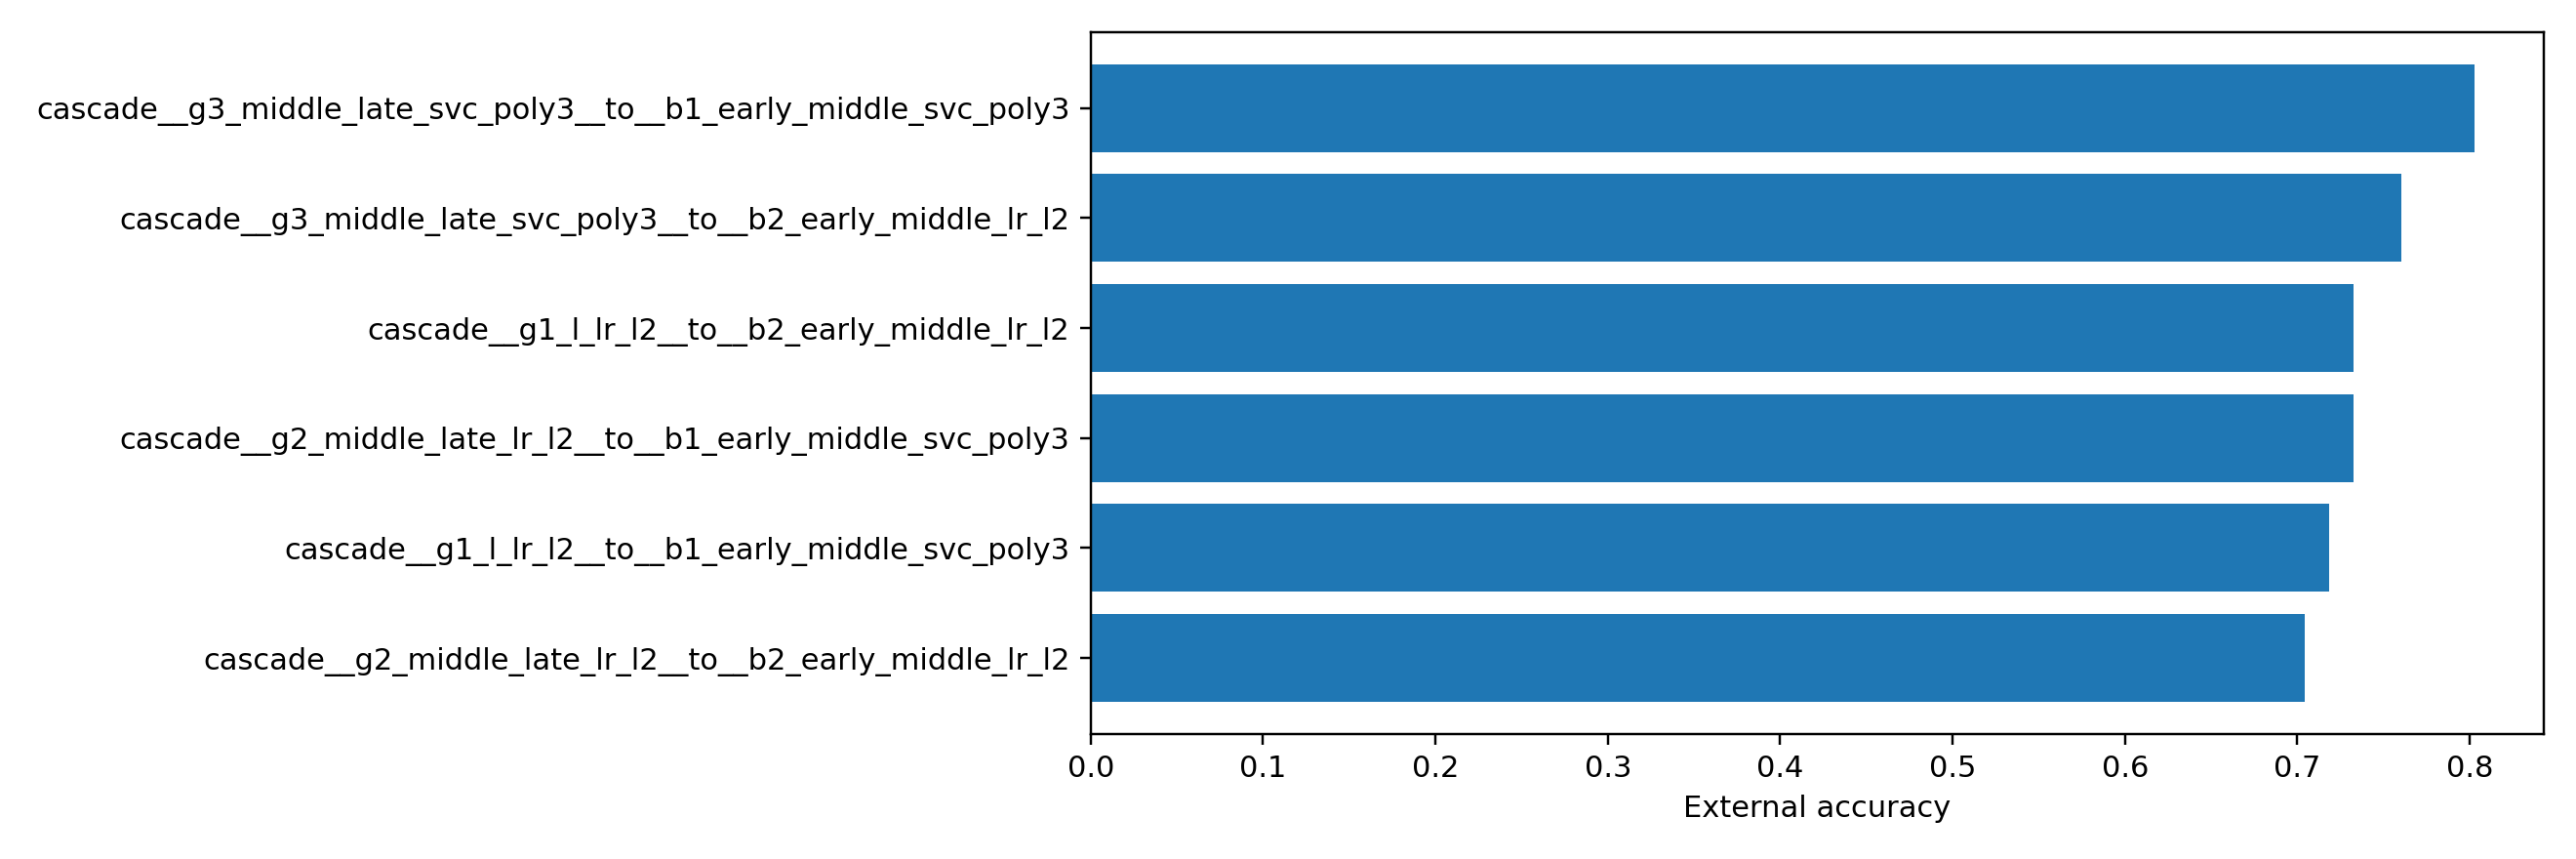

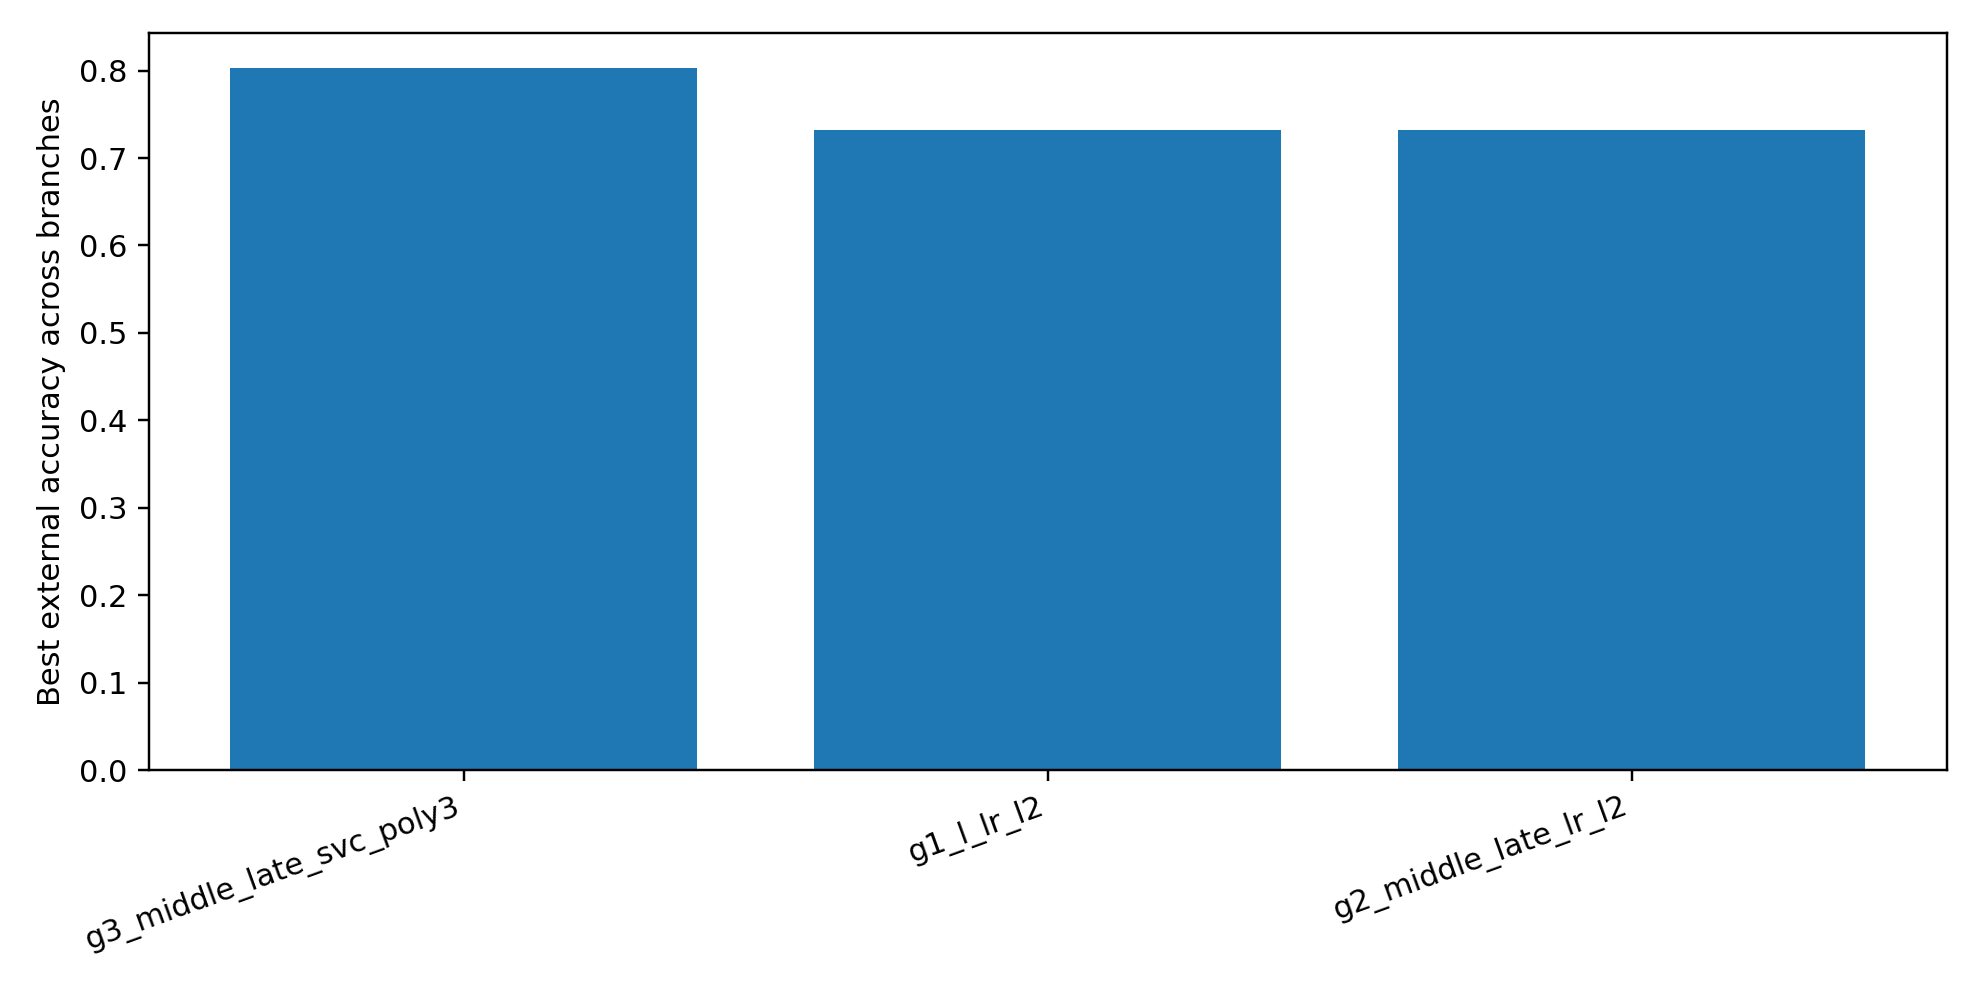

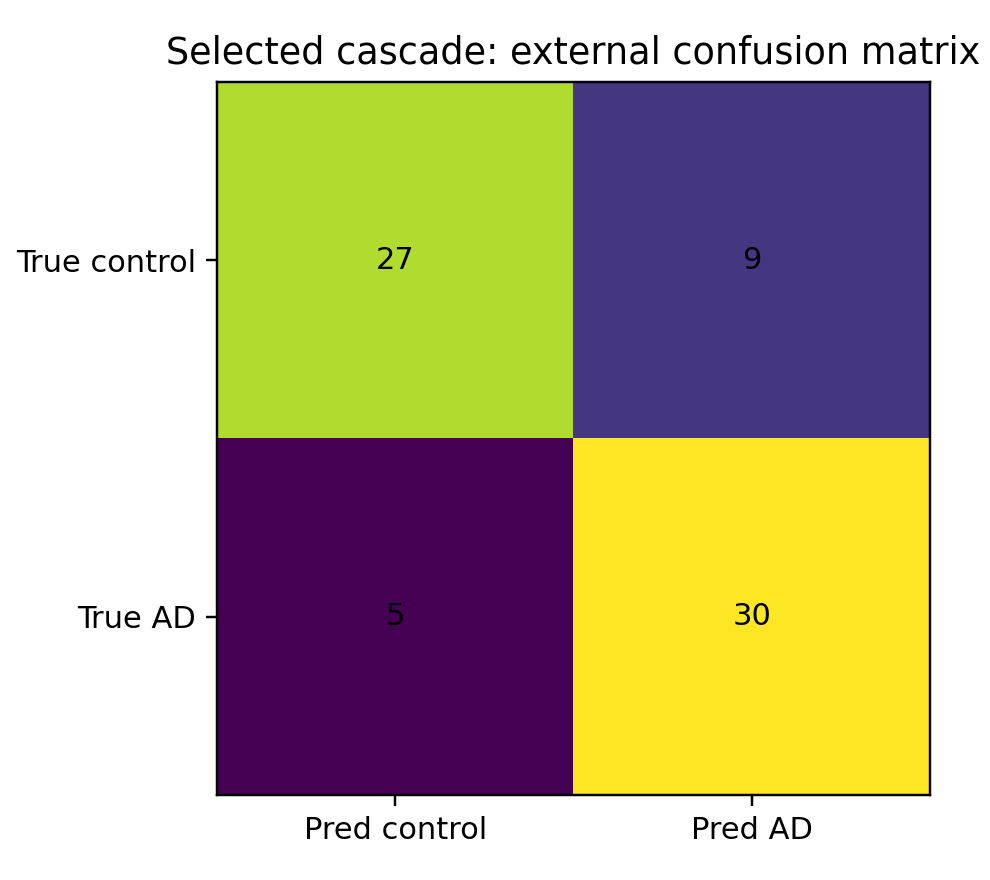

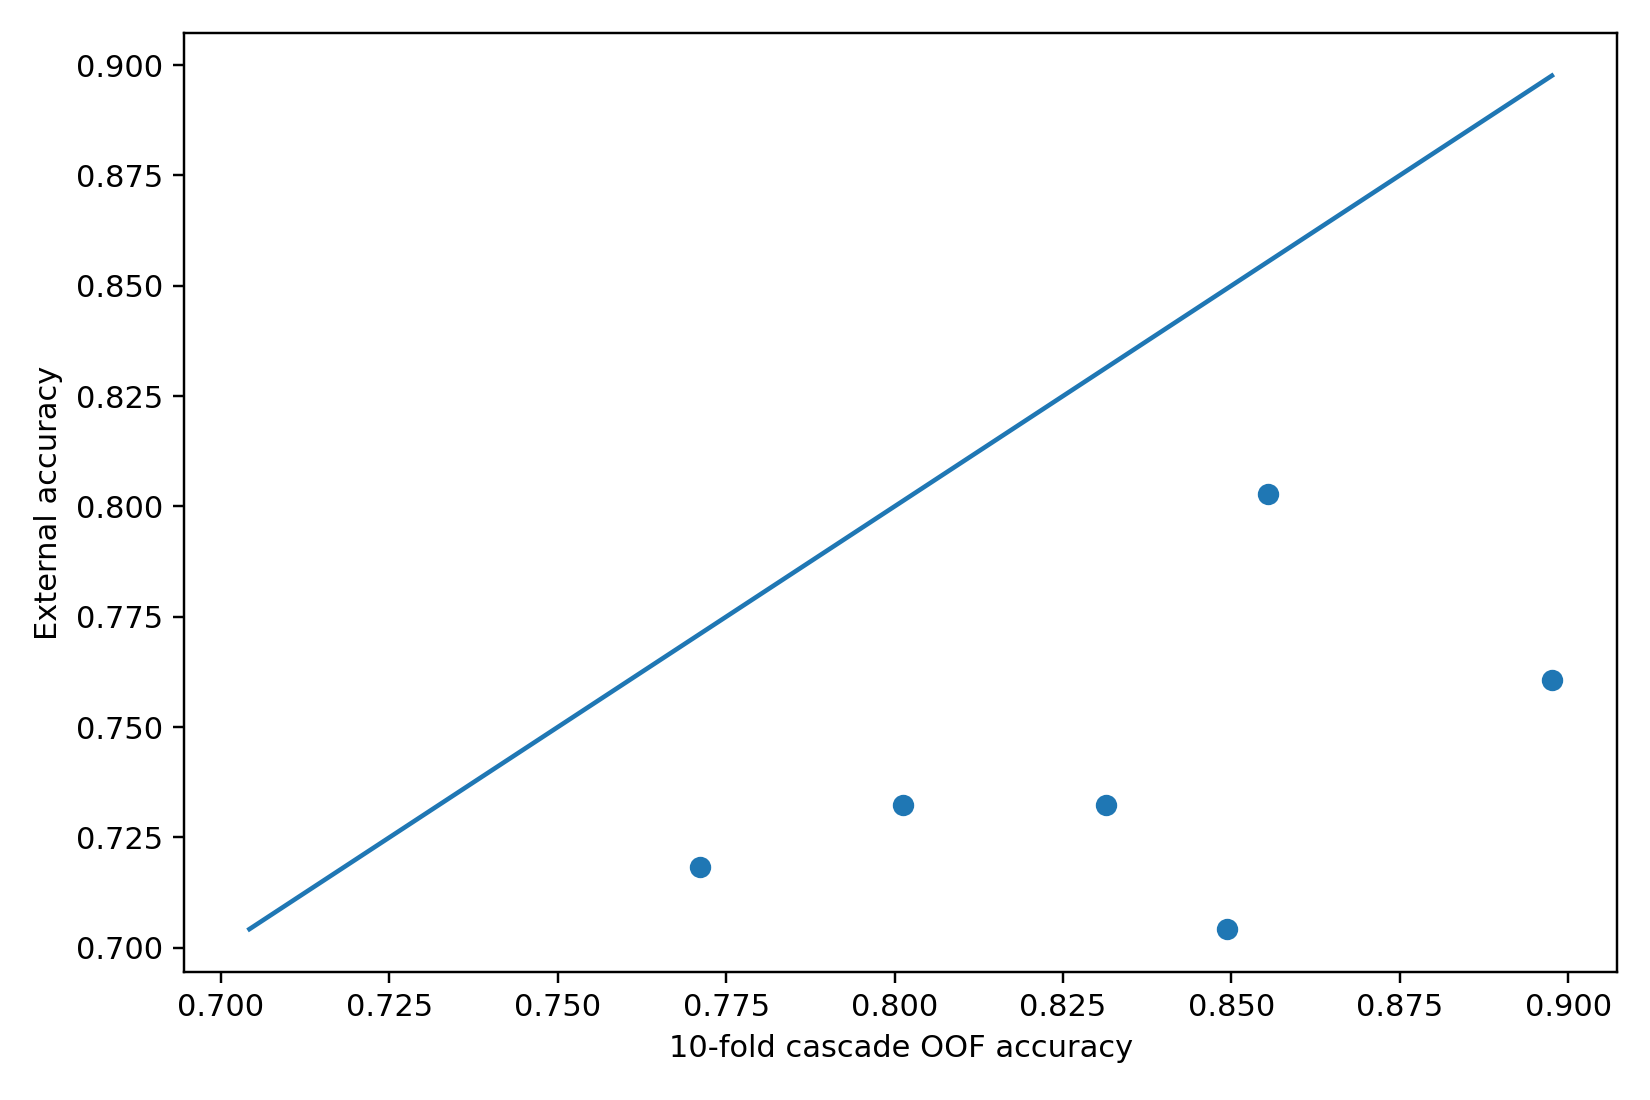

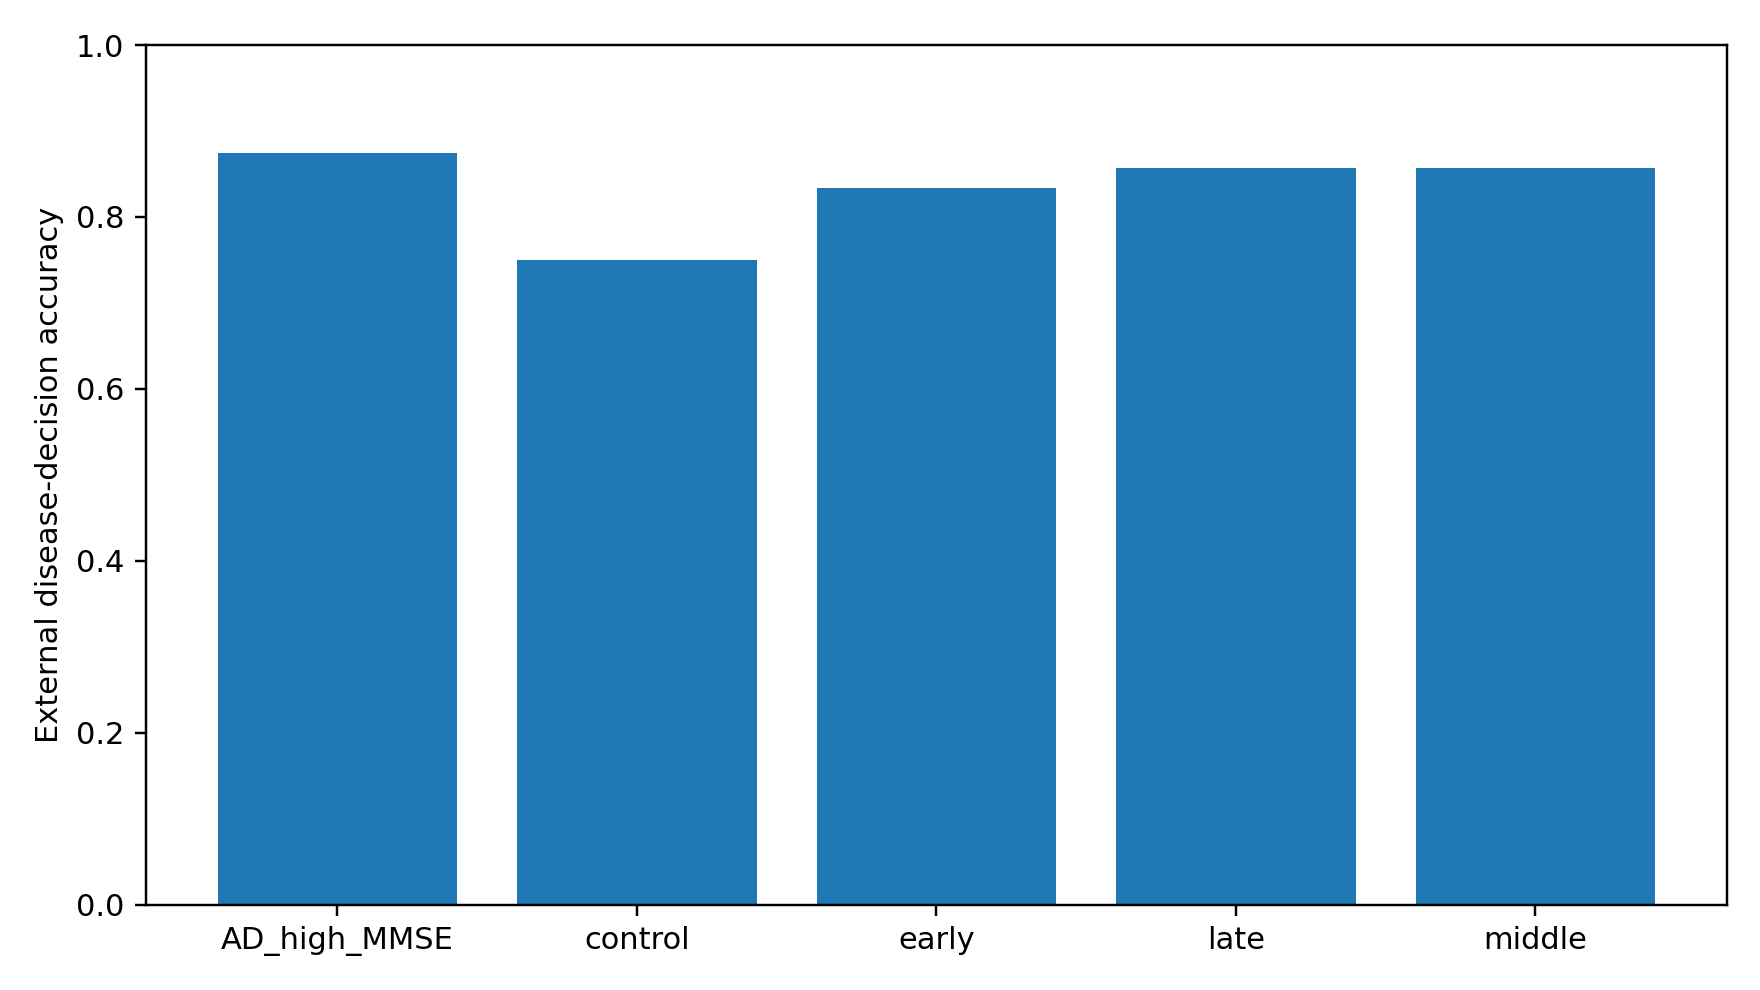

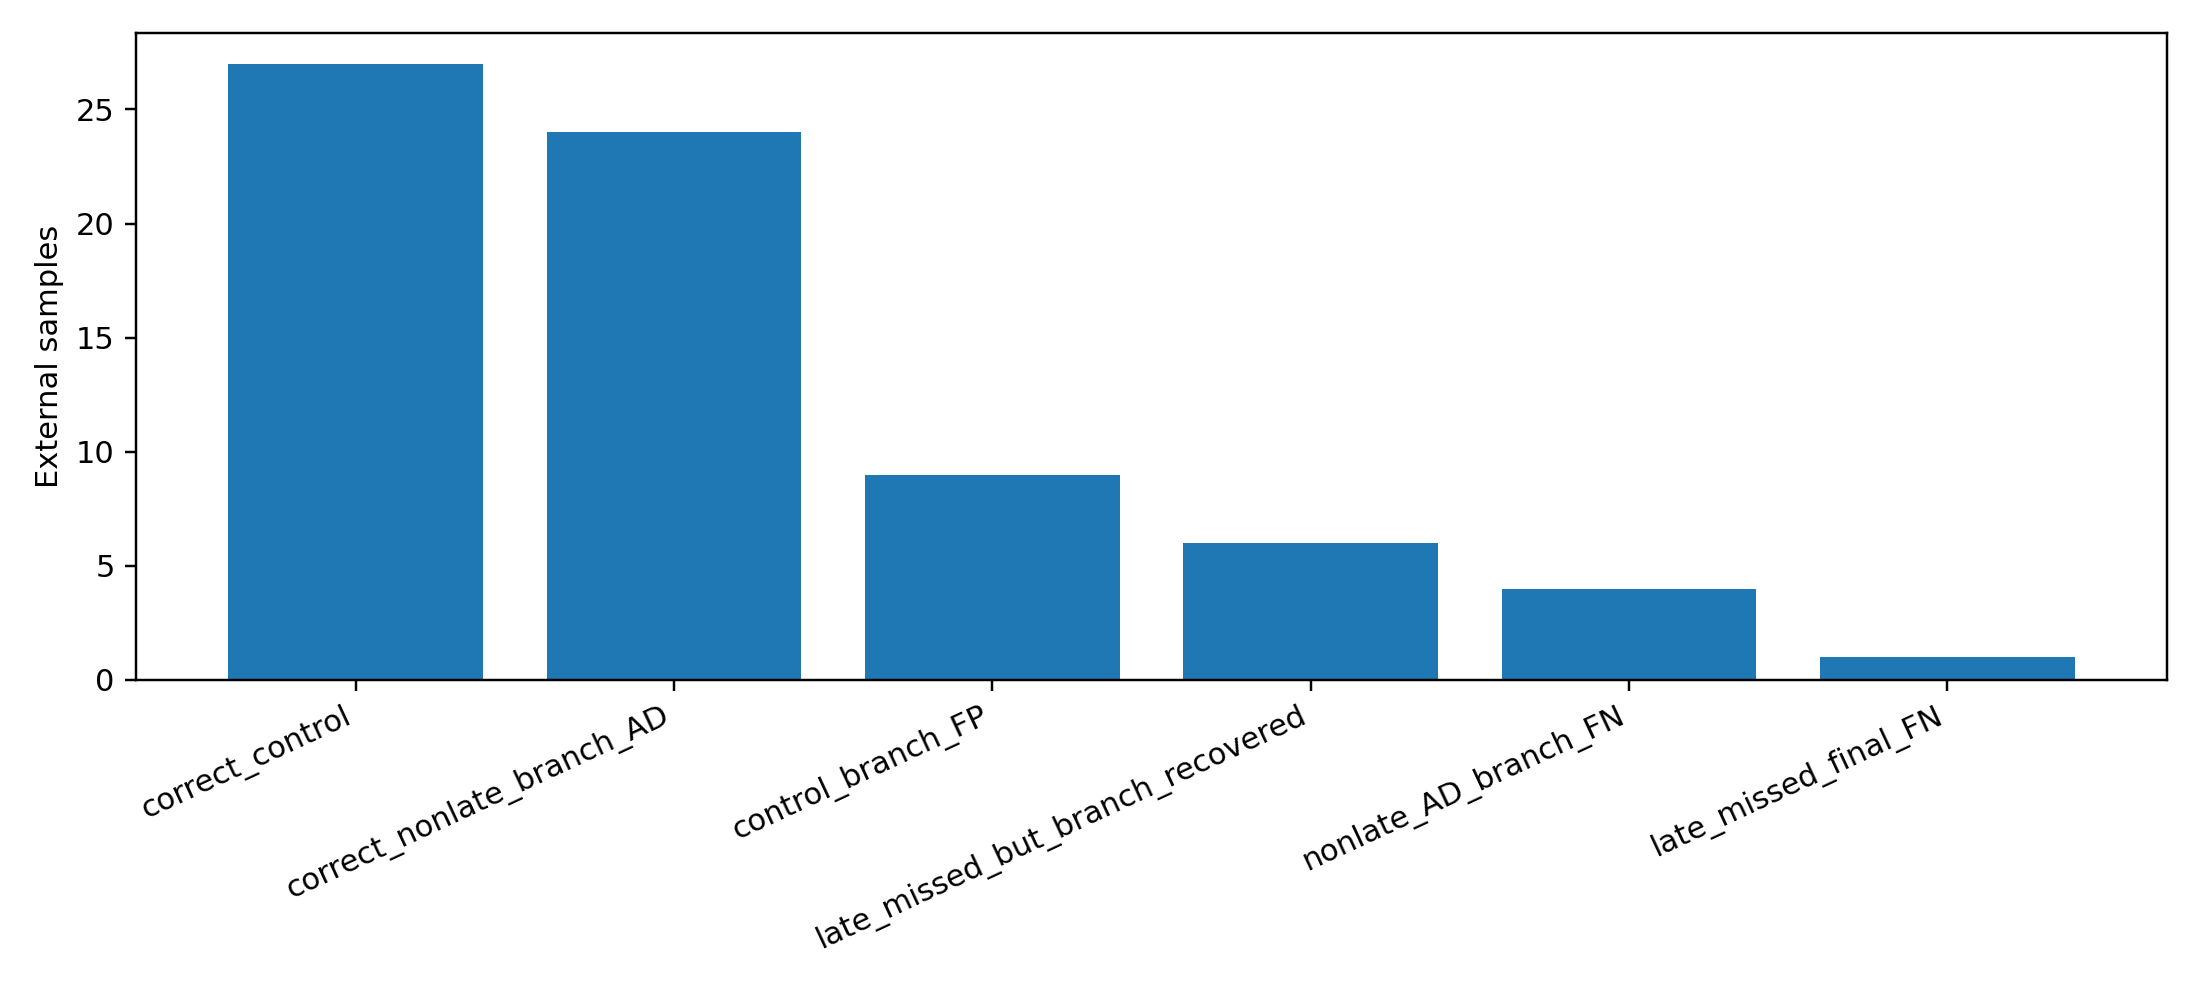

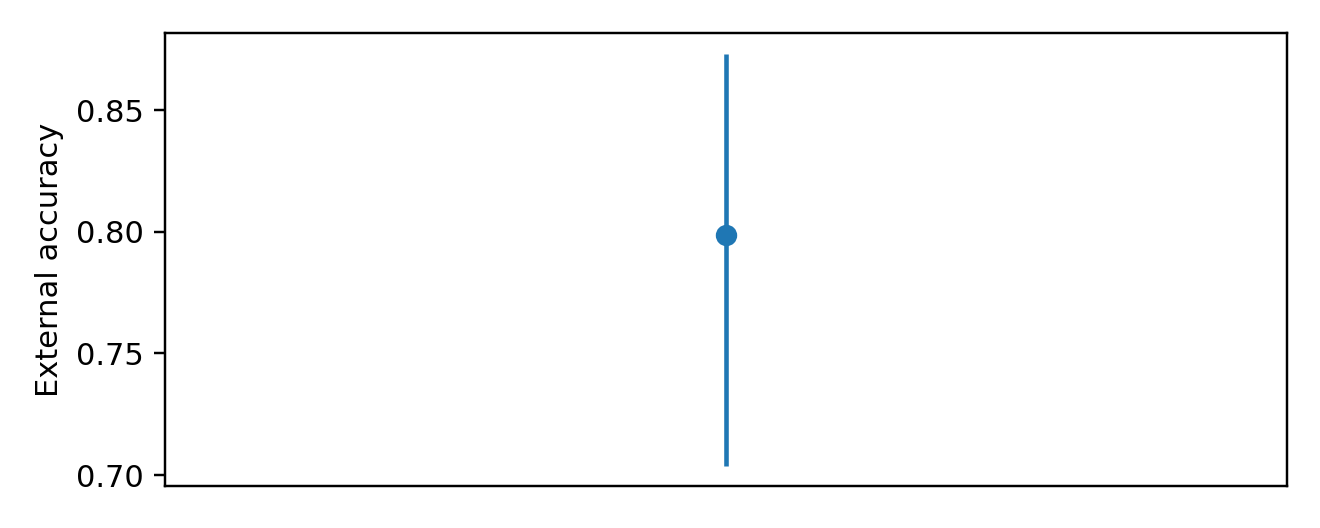

In [7]:
for filename in summary.get("figures", []):
    path = FINAL / "figures" / filename
    if path.exists():
        display(Image(filename=str(path)))